In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec

import scipy.stats as stats

import torch

from transformers import GPT2Tokenizer, GPT2LMHeadModel, logging

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
logging.set_verbosity_error()

tokenizer = GPT2Tokenizer.from_pretrained("gpt2-large")
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained("gpt2-large").to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

In [4]:
# generated by claude
sentences = [

    # sentences with "toothpaste," "toothbrush," "floss," or "mouthwash"

    "She bought a new electric toothbrush that has a timer built in.",
    "I ran out of toothpaste this morning and had to borrow some from my roommate.",
    "After brushing, he used mouthwash to freshen his breath before the interview.",
    "The dentist recommended using dental floss daily to prevent gum disease.",
    "My travel toothbrush folds up to fit easily in my toiletry bag.",
    "The minty toothpaste made my mouth feel clean and refreshed.",
    "He swished the mouthwash around for thirty seconds before spitting it out.",
    "Waxed floss works better for me because it doesn't fray between my teeth.",
    "The hotel provided complimentary toothbrush and toothpaste in the bathroom.",
    "My children prefer fruit-flavored toothpaste over mint varieties.",
    "The dentist gave me a free sample of antibacterial mouthwash after my cleaning.",
    "Learning to floss properly took me several attempts and a lesson from my hygienist.",
    "I keep a spare toothbrush at work for after-lunch brushing.",
    "The natural toothpaste didn't contain fluoride but still cleaned effectively.",
    "Using mouthwash too frequently can disrupt the beneficial bacteria in your mouth.",
    "Water flossers are a good alternative for people who struggle with traditional floss.",
    "The bristles on my toothbrush were frayed, indicating it was time for a replacement.",
    "She squeezed the last bit of toothpaste from the tube by rolling it up from the bottom.",
    "Alcohol-free mouthwash is often recommended for people with sensitive gums.",
    "The dental hygienist demonstrated the correct technique for using floss picks.",

    # sentences with "dishwasher," "nightstand," "bookshelf," or "doorknob"

    "The dishwasher hummed quietly as it ran through its cleaning cycle.",
    "She placed her reading glasses on the nightstand before turning off the lamp.",
    "The antique bookshelf dominated the wall with its impressive collection of leather-bound books.",
    "He turned the doorknob slowly, trying not to wake the sleeping baby in the next room.",
    "Loading the dishwasher efficiently is truly an art form that few have mastered.",
    "The water glass on the nightstand had left a circular mark on the wooden surface.",
    "They installed a new bookshelf to accommodate their growing collection of novels.",
    "The brass doorknob gleamed after being polished with special metal cleaner.",
    "The dishwasher leaked water onto the kitchen floor, creating a small puddle.",
    "Her phone alarm buzzed loudly on the nightstand, jolting her awake.",
    "The bookshelf sagged in the middle from the weight of encyclopedias and textbooks.",
    "The doorknob came loose in his hand when he tried to enter the storage room.",
    "Energy-efficient dishwasher models use significantly less water than older versions.",
    "The small drawer in the nightstand contained a journal and several pens.",
    "The children's favorite picture books were displayed on the lowest shelf of the bookshelf.",
    "The vintage glass doorknob was the original fixture from when the house was built.",
    "He loaded the dirty dishes into the dishwasher while singing along to the radio.",
    "The prescription medication and reading light sat on the nightstand within easy reach.",
    "They secured the tall bookshelf to the wall to prevent it from tipping over.",
    "The decorative doorknob added a touch of elegance to the otherwise plain door."
]

n_sentences = len(sentences)
labels = (np.linspace(0,1,n_sentences)>.5).astype(int)
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
# Create a list of tokens with each target word
targetwords = [' toothpaste',' toothbrush',' floss',    ' mouthwash',
               ' dishwasher',' nightstand',' bookshelf',' doorknob'  ]

targtoks = []

for word in targetwords:
  token_ids = tokenizer.encode(word)
  targtoks.append(token_ids)
  print(f'{word} contains {len(token_ids)} tokens and they are {[tokenizer.decode(t) for t in token_ids]}')

 toothpaste contains 2 tokens and they are [' tooth', 'paste']
 toothbrush contains 2 tokens and they are [' tooth', 'brush']
 floss contains 2 tokens and they are [' fl', 'oss']
 mouthwash contains 2 tokens and they are [' mouth', 'wash']
 dishwasher contains 2 tokens and they are [' dish', 'washer']
 nightstand contains 2 tokens and they are [' night', 'stand']
 bookshelf contains 3 tokens and they are [' books', 'he', 'lf']
 doorknob contains 3 tokens and they are [' do', 'ork', 'nob']


In [6]:
# Tokenize sentences
tokens = tokenizer(sentences, return_tensors="pt", padding=True)

seq_len = tokens['input_ids'].shape[-1]

tokens['input_ids'][0],tokens['attention_mask'][0]


(tensor([ 3347,  5839,   257,   649,  5186, 16162, 32680,   326,   468,   257,
         19781,  3170,   287,    13, 50256, 50256, 50256, 50256, 50256, 50256]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]))

In [7]:
# Find target tokens in each sentence and store the end index (j) and which target matched (t)

targetlocs = np.full(n_sentences, -1, dtype=int)  # -1 means "not found"
targetvals = np.full(n_sentences, -1, dtype=int)

input_ids = tokens["input_ids"]            # shape: (batch, seq_len)
attn = tokens["attention_mask"]            # shape: (batch, seq_len)
seq_len = input_ids.shape[1]

for i in range(input_ids.shape[0]):
    # only search within real tokens (ignore padding)
    valid_len = int(attn[i].sum().item())

    for t, target_tokens in enumerate(targtoks):
        target_tokens_t = torch.tensor(target_tokens, dtype=input_ids.dtype, device=input_ids.device)
        L = len(target_tokens)

        for j in range(L, valid_len + 1):  # j is END (exclusive) of window
            window = input_ids[i, j-L:j]
            if torch.equal(window, target_tokens_t):
                targetlocs[i] = j          # end position
                targetvals[i] = t          # which target word
                decoded = tokenizer.decode(window.tolist())
                print(f"Sentence {i:2d} matched target {t} ending at index {j-1:2d}: '{decoded}'")
                break

        # if targetvals[i] != -1:  # already found a target in this sentence
            # break

Sentence  0 matched target 1 ending at index  6: ' toothbrush'
Sentence  1 matched target 0 ending at index  5: ' toothpaste'
Sentence  2 matched target 3 ending at index  6: ' mouthwash'
Sentence  3 matched target 2 ending at index  6: ' floss'
Sentence  4 matched target 1 ending at index  3: ' toothbrush'
Sentence  5 matched target 0 ending at index  4: ' toothpaste'
Sentence  6 matched target 3 ending at index  5: ' mouthwash'
Sentence  7 matched target 2 ending at index  4: ' floss'
Sentence  8 matched target 0 ending at index  8: ' toothpaste'
Sentence  8 matched target 1 ending at index  5: ' toothbrush'
Sentence  9 matched target 0 ending at index  8: ' toothpaste'
Sentence 10 matched target 3 ending at index 11: ' mouthwash'
Sentence 11 matched target 2 ending at index  3: ' floss'
Sentence 12 matched target 1 ending at index  5: ' toothbrush'
Sentence 13 matched target 0 ending at index  3: ' toothpaste'
Sentence 14 matched target 3 ending at index  2: ' mouthwash'
Sentence 15

In [8]:
# Function to find all matches of target words in each of the sentences
def find_all_targets_unfold(tokens, targtoks, tokenizer):
    input_ids = tokens["input_ids"]
    attn = tokens["attention_mask"]

    all_matches = []  # list (per sentence) of list of matches

    for i in range(input_ids.shape[0]):
        valid_len = int(attn[i].sum().item())
        sent = input_ids[i, :valid_len]

        sent_matches = []

        for t, tok_list in enumerate(targtoks):
            pat = torch.tensor(tok_list, dtype=sent.dtype, device=sent.device)
            L = pat.numel()
            if valid_len < L:
                continue

            windows = sent.unfold(0, L, 1)            # (valid_len-L+1, L)
            hits = (windows == pat).all(dim=1)        # bool vector length (valid_len-L+1)

            if hits.any():
                starts = hits.nonzero(as_tuple=False).squeeze(1).tolist()
                for s in starts:
                    e = s + L
                    span_ids = sent[s:e].tolist()
                    sent_matches.append((t, s, e, tokenizer.decode(span_ids)))

        # sort matches left-to-right in the sentence (by start index)
        sent_matches.sort(key=lambda x: x[1])
        all_matches.append(sent_matches)

    return all_matches

In [9]:
all_matches = find_all_targets_unfold(tokens, targtoks, tokenizer)

for i, matches in enumerate(all_matches):
    print(f"\nSentence {i}: {sentences[i]}")
    if not matches:
        print("  (no target found)")
    else:
        for t, s, e, dec in matches:
            print(f"  target {t:>2} @ [{s}:{e}] -> '{dec}'")


Sentence 0: She bought a new electric toothbrush that has a timer built in.
  target  1 @ [5:7] -> ' toothbrush'

Sentence 1: I ran out of toothpaste this morning and had to borrow some from my roommate.
  target  0 @ [4:6] -> ' toothpaste'

Sentence 2: After brushing, he used mouthwash to freshen his breath before the interview.
  target  3 @ [5:7] -> ' mouthwash'

Sentence 3: The dentist recommended using dental floss daily to prevent gum disease.
  target  2 @ [5:7] -> ' floss'

Sentence 4: My travel toothbrush folds up to fit easily in my toiletry bag.
  target  1 @ [2:4] -> ' toothbrush'

Sentence 5: The minty toothpaste made my mouth feel clean and refreshed.
  target  0 @ [3:5] -> ' toothpaste'

Sentence 6: He swished the mouthwash around for thirty seconds before spitting it out.
  target  3 @ [4:6] -> ' mouthwash'

Sentence 7: Waxed floss works better for me because it doesn't fray between my teeth.
  target  2 @ [3:5] -> ' floss'

Sentence 8: The hotel provided complimentary

In [10]:
for i, t in enumerate(tokens['input_ids'][1]):
  print(f'Index: {i:>2}| Token-id: {t.item():>5} | Token: {tokenizer.decode(t):10}')

Index:  0| Token-id:    40 | Token: I         
Index:  1| Token-id:  4966 | Token:  ran      
Index:  2| Token-id:   503 | Token:  out      
Index:  3| Token-id:   286 | Token:  of       
Index:  4| Token-id: 16162 | Token:  tooth    
Index:  5| Token-id: 34274 | Token: paste     
Index:  6| Token-id:   428 | Token:  this     
Index:  7| Token-id:  3329 | Token:  morning  
Index:  8| Token-id:   290 | Token:  and      
Index:  9| Token-id:   550 | Token:  had      
Index: 10| Token-id:   284 | Token:  to       
Index: 11| Token-id:  8804 | Token:  borrow   
Index: 12| Token-id:   617 | Token:  some     
Index: 13| Token-id:   422 | Token:  from     
Index: 14| Token-id:   616 | Token:  my       
Index: 15| Token-id: 33305 | Token:  roommate 
Index: 16| Token-id:    13 | Token: .         
Index: 17| Token-id: 50256 | Token: <|endoftext|>
Index: 18| Token-id: 50256 | Token: <|endoftext|>
Index: 19| Token-id: 50256 | Token: <|endoftext|>


In [11]:
u, c = np.unique(targetvals, return_counts=True)

for uu, cc in zip(u,c):
  print(f'Target {uu} appears in {cc} sentences ({targetwords[uu]})')

Target 0 appears in 5 sentences ( toothpaste)
Target 1 appears in 5 sentences ( toothbrush)
Target 2 appears in 5 sentences ( floss)
Target 3 appears in 5 sentences ( mouthwash)
Target 4 appears in 5 sentences ( dishwasher)
Target 5 appears in 5 sentences ( nightstand)
Target 6 appears in 5 sentences ( bookshelf)
Target 7 appears in 5 sentences ( doorknob)


#### **Implant hooks after the c_proj layer**

In [12]:
activations = {}

for i in range(model.config.n_layer):
  hookname = f'mlp_c_proj_layer{i}'
  model.transformer.h[i].mlp.c_proj.register_forward_hook(
      lambda module, input, output, hname=hookname: activations.__setitem__(hname, output.detach())
  )

In [13]:
# Push the texts through the model
tokens = tokenizer(sentences, return_tensors='pt', padding=True).to(device)

with torch.no_grad(): model(**tokens)

In [14]:
activations['mlp_c_proj_layer4'].shape

torch.Size([40, 20, 1280])

In [15]:
target_activations = np.zeros((model.config.n_layer, n_sentences, activations['mlp_c_proj_layer0'].shape[-1]))

for senti in range(n_sentences):
  for layeri in range(model.config.n_layer):
    target_activations[layeri,senti,:] = activations[f'mlp_c_proj_layer{layeri}'][senti, targetlocs[senti],:].cpu().numpy()

target_activations.shape

(36, 40, 1280)

### **Run t-test and p-test on two categories for each neuron**

In [16]:
# two-sample t-test on all neurons between two categories
n_sentences = len(sentences)
labels = (np.linspace(0,1,n_sentences)>.5).astype(int)

tests = stats.ttest_ind(target_activations[:,labels==0,:], target_activations[:,labels==1,:], axis=1)

# Extract t and p values
data1_t = tests.statistic
data1_p = tests.pvalue

print(data1_t.shape)

(36, 1280)


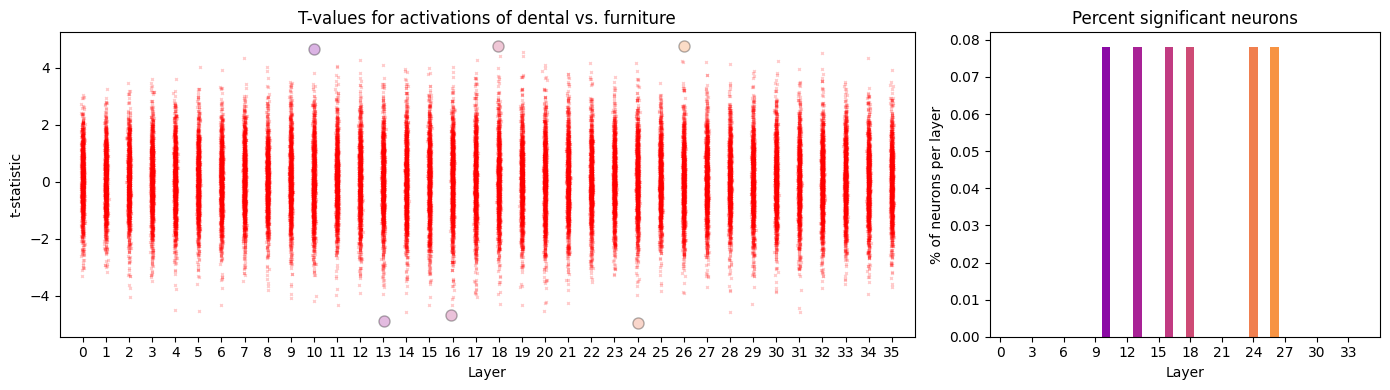

In [17]:
# significance threshold (p<.05, Bonferroni)
sigPthresh = .05 / target_activations.shape[-1]

# setup the figure
fig = plt.figure(figsize=(14,4))
gs = GridSpec(1,3,figure=fig)
ax1 = fig.add_subplot(gs[:2])
ax2 = fig.add_subplot(gs[2])


# loop over layers
numsig = np.zeros(model.config.n_layer)
for layeri in range(model.config.n_layer):

  # find the significant neurons
  issig = data1_p[layeri,:]<sigPthresh
  numsig[layeri] = 100*issig.mean()

  # draw them
  ax1.plot(np.random.normal(loc=layeri,scale=.03,size=np.sum(~issig)),data1_t[layeri,~issig],'rx',alpha=.2,markersize=2)
  ax1.plot(np.random.normal(loc=layeri,scale=.03,size=np.sum(issig)),data1_t[layeri,issig],'ko',markerfacecolor=mpl.cm.plasma(layeri/model.config.n_layer),markersize=8,alpha=.3)

ax1.set(xlabel='Layer',ylabel='t-statistic',xticks=range(model.config.n_layer),
        xlim=[-1,model.config.n_layer],title='T-values for activations of dental vs. furniture')


# percent significant neurons per layer
ax2.bar(range(model.config.n_layer),numsig,color=mpl.cm.plasma(np.linspace(0,1,model.config.n_layer)))
ax2.set(xlabel='Layer',ylabel='% of neurons per layer',xticks=range(0,model.config.n_layer,3),
        xlim=[-1,model.config.n_layer],title='Percent significant neurons')

plt.tight_layout()
plt.show()

In [18]:
# Find most selective neurons
# Absolute t-values
abs_t = np.abs(data1_t)

# Find top K neurons across entire model
K = 10

flat_indices = np.argsort(abs_t.ravel())[::-1][:K]

top_neurons = []

for idx in flat_indices:
    layer = idx // abs_t.shape[1]
    neuron = idx % abs_t.shape[1]
    top_neurons.append((layer, neuron, data1_t[layer, neuron]))

top_neurons

[(np.int64(24), np.int64(41), np.float64(-4.947461217849307)),
 (np.int64(13), np.int64(19), np.float64(-4.867619690851445)),
 (np.int64(26), np.int64(446), np.float64(4.759207798661061)),
 (np.int64(18), np.int64(1226), np.float64(4.749103441547222)),
 (np.int64(16), np.int64(1083), np.float64(-4.687981329517712)),
 (np.int64(10), np.int64(834), np.float64(4.676091677598874)),
 (np.int64(28), np.int64(602), np.float64(-4.580775784568068)),
 (np.int64(14), np.int64(1147), np.float64(-4.563697915834951)),
 (np.int64(31), np.int64(286), np.float64(-4.563193087723576)),
 (np.int64(19), np.int64(406), np.float64(4.562866600731213))]

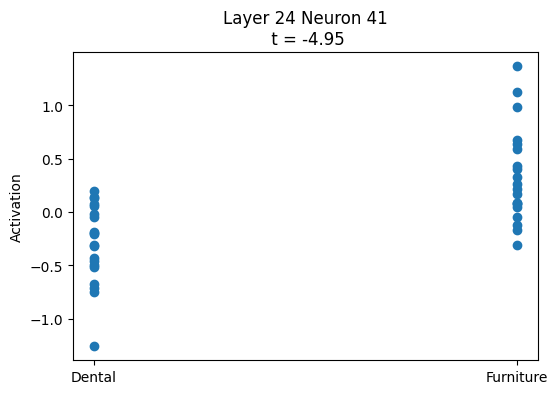

In [19]:
# Visualize one selective neuron
layer, neuron, tval = top_neurons[0]

acts = target_activations[layer, :, neuron]

plt.figure(figsize=(6,4))

plt.scatter(labels, acts)
plt.xticks([0,1], ['Dental','Furniture'])
plt.ylabel('Activation')
plt.title(f'Layer {layer} Neuron {neuron}\n t = {tval:.2f}')
plt.show()

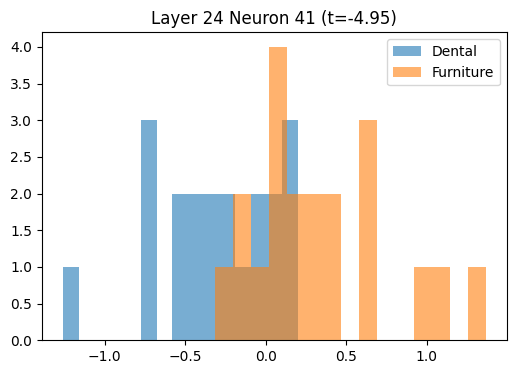

In [20]:
dental = acts[labels==0]
furniture = acts[labels==1]

plt.figure(figsize=(6,4))

plt.hist(dental, bins=15, alpha=.6, label='Dental')
plt.hist(furniture, bins=15, alpha=.6, label='Furniture')

plt.legend()
plt.title(f'Layer {layer} Neuron {neuron} (t={tval:.2f})')
plt.show()

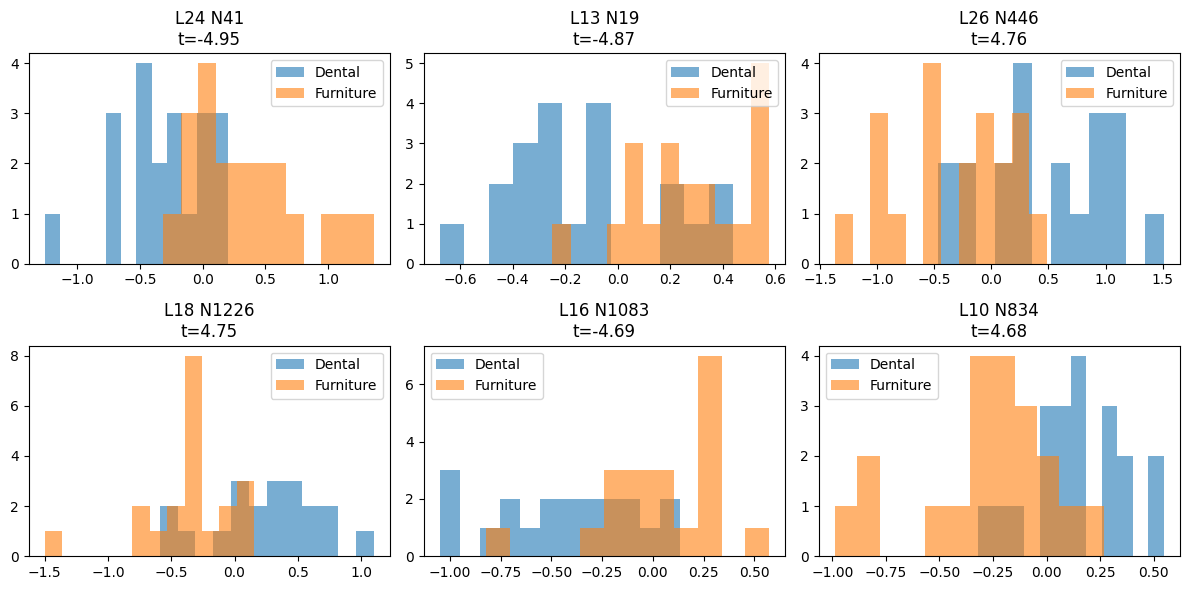

In [21]:
# Plot top neurons across layers
fig, axes = plt.subplots(2, 3, figsize=(12,6))

for ax, (layer, neuron, tval) in zip(axes.ravel(), top_neurons[:6]):

    acts = target_activations[layer,:,neuron]
    dental = acts[labels==0]
    furniture = acts[labels==1]

    ax.hist(dental, bins=12, alpha=.6, label='Dental')
    ax.hist(furniture, bins=12, alpha=.6, label="Furniture")

    ax.set_title(f'L{layer} N{neuron}\nt={tval:.2f}')

    ax.legend()

plt.tight_layout()
plt.show()

# Per target activations for t-max and t-min neurons

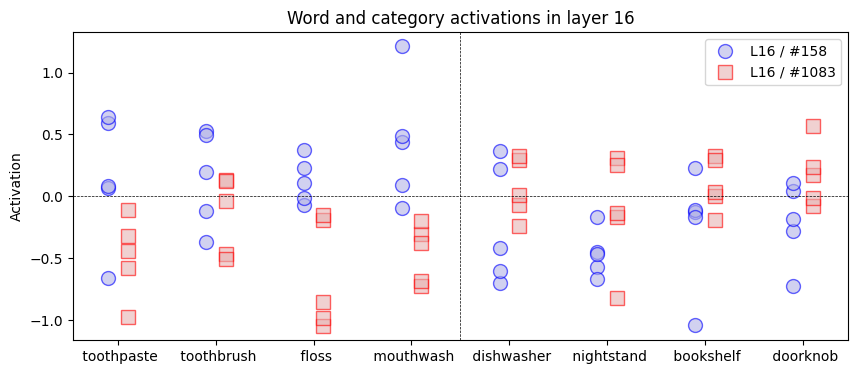

In [22]:
# Selecting one layer for the t-max and t-min
layeri = 16

# Derive indices with max and min t-values
maxt = np.argmax(data1_t[layeri,:])
mint = np.argmin(data1_t[layeri,:])

# plot the figure!
plt.figure(figsize=(10,4))
for i in range(targetvals.max()+1):

  # find max activations for this target and plot
  ys = target_activations[layeri,targetvals==i,maxt]
  plt.plot(np.full(ys.shape,i-.1),ys,'bo',markerfacecolor=[.7,.7,.9],alpha=.6,markersize=10)

  # find max activations for this target and plot
  ys = target_activations[layeri,targetvals==i,mint]
  plt.plot(np.full(ys.shape,i+.1),ys,'rs',markerfacecolor=[.9,.7,.7],alpha=.6,markersize=10)

plt.axhline(0,color='k',linestyle='--',linewidth=.5)
plt.axvline(3.5,color='k',linestyle='--',linewidth=.5)
plt.gca().set(xticks=range(targetvals.max()+1),xticklabels=targetwords,ylabel='Activation',
              title=f'Word and category activations in layer {layeri}')
plt.legend([f'L{layeri} / #{maxt}',f'L{layeri} / #{mint}'])

plt.show()

# **Tokenize Multi-target datasets**

In [23]:
# test sentences with both dental and furniture words
sentences_mix = [
    "She left her toothbrush on the nightstand after falling asleep reading.",
    "The tube of toothpaste rolled off the bookshelf and landed on the floor.",
    "He gargled mouthwash while waiting for the dishwasher cycle to finish.",
    "I keep dental floss in the small drawer of my nightstand for convenient access.",
    "The toothpaste cap fell behind the bookshelf, making it difficult to retrieve.",
    "Her electric toothbrush charging base sits next to the doorknob on the bathroom counter.",
    "After using mouthwash, he placed the cap back on and returned it to the bookshelf.",
    "The floss container was knocked off the nightstand by the cat during the night.",
    "He squeezed the last bit of toothpaste from the tube before placing it in the dishwasher's utensil basket.",
    "The mouthwash spilled when he bumped into the doorknob while carrying too many items.",
    "She organized her bathroom supplies, placing her toothbrush and floss in a basket on top of the bookshelf.",
    "The minty smell of toothpaste lingered near the nightstand where she had been brushing her teeth.",
    "He accidentally splashed mouthwash on the dishwasher while rinsing his mouth.",
    "The children's floss picks were stored in a decorative jar on the bookshelf.",
    "Her toothbrush fell from her hand as she reached for the doorknob in a hurry.",
    "The blue toothpaste stained the wood of the nightstand when the cap wasn't secured properly.",
    "He kept a travel-sized mouthwash in the drawer of his nightstand for freshening up in the morning.",
    "The floss got tangled around the doorknob when the package fell and unraveled.",
    "She placed her toothbrush in the dishwasher's silverware basket to sanitize it thoroughly.",
    "The bathroom renovation included a built-in bookshelf with designated spots for toothpaste, mouthwash, and floss."
]

In [24]:
tokens_mix = tokenizer(sentences_mix, return_tensors='pt', padding=True)
seq_len_mix = tokens_mix['input_ids'].shape[-1]
n_sentences_mix = len(sentences_mix)

In [25]:
tokens_mix['input_ids'][0],tokens_mix['attention_mask'][0]

(tensor([ 3347,  1364,   607, 16162, 32680,   319,   262,  1755,  1481,   706,
          7463, 16039,  3555,    13, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]))

In [26]:
targetvals_mat = np.full((n_sentences_mix,seq_len_mix),-1,dtype=int)

# loop over sentences
for senti in range(n_sentences_mix):

  # loop over targets
  for targi in range(len(targtoks)):

    # get target length (number of tokens)
    targlen = len(targtoks[targi])

    # loop over tokens in sentence
    for ti in range(targlen,seq_len_mix+1):

      # if this mini-sequence matches the target
      if torch.equal(tokens_mix['input_ids'][senti,ti-targlen:ti],torch.tensor(targtoks[targi])):
        targetvals_mat[senti,ti-1] = targi
        print(f"Sentence {senti:2} target {targetvals_mat[senti,ti-1]} at index {ti-1:2}: '{tokenizer.decode(tokens_mix['input_ids'][senti,ti-targlen:ti])}'")

Sentence  0 target 1 at index  4: ' toothbrush'
Sentence  0 target 5 at index  8: ' nightstand'
Sentence  1 target 0 at index  4: ' toothpaste'
Sentence  1 target 6 at index 10: ' bookshelf'
Sentence  2 target 3 at index  4: ' mouthwash'
Sentence  2 target 4 at index 10: ' dishwasher'
Sentence  3 target 2 at index  4: ' floss'
Sentence  3 target 5 at index 12: ' nightstand'
Sentence  4 target 0 at index  2: ' toothpaste'
Sentence  4 target 6 at index  9: ' bookshelf'
Sentence  5 target 1 at index  3: ' toothbrush'
Sentence  5 target 7 at index 12: ' doorknob'
Sentence  6 target 3 at index  3: ' mouthwash'
Sentence  6 target 6 at index 18: ' bookshelf'
Sentence  7 target 2 at index  2: ' floss'
Sentence  7 target 5 at index  9: ' nightstand'
Sentence  8 target 0 at index  7: ' toothpaste'
Sentence  8 target 4 at index 17: ' dishwasher'
Sentence  9 target 3 at index  2: ' mouthwash'
Sentence  9 target 7 at index 11: ' doorknob'
Sentence 10 target 1 at index  9: ' toothbrush'
Sentence 10 

In [27]:
u,c = np.unique(targetvals_mat.flatten(),return_counts=True)
for uu,cc in zip(u,c):
  if uu>-1:
    print(f'{cc} appearances of target {uu} ("{targetwords[uu]}")')

6 appearances of target 0 (" toothpaste")
5 appearances of target 1 (" toothbrush")
6 appearances of target 2 (" floss")
6 appearances of target 3 (" mouthwash")
4 appearances of target 4 (" dishwasher")
6 appearances of target 5 (" nightstand")
6 appearances of target 6 (" bookshelf")
4 appearances of target 7 (" doorknob")


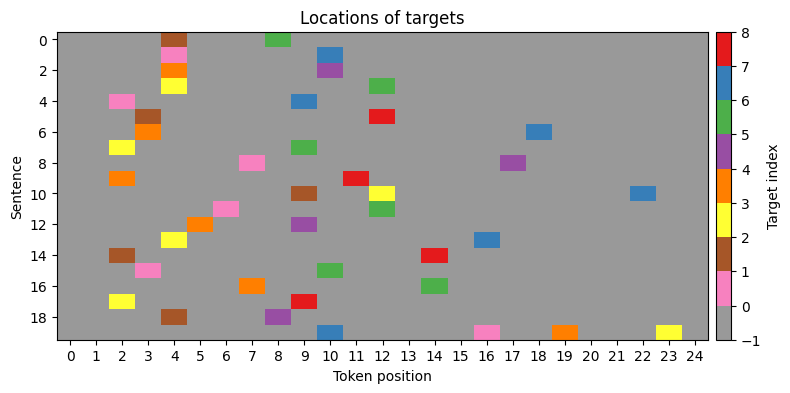

In [28]:
fig,ax = plt.subplots(1,figsize=(10,4))

# Note: The colormap in the video only contains 8 possible colors, so 6&7 were mapped to the same color.
#       The code here correctly assigns a unique color to each label (and -1).
cm_name = 'Set1_r'

ax.imshow(targetvals_mat,aspect='auto',cmap=cm_name,vmin=-2,vmax=8)
ax.set(xlabel='Token position',ylabel='Sentence',title='Locations of targets',
              xticks=range(seq_len_mix),yticks=range(0,n_sentences_mix,2))

# discrete colorbar
cmap = mpl.colormaps[cm_name]
norm = mpl.colors.BoundaryNorm(np.arange(-1,9), cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm,ax=ax,pad=.01,label='Target index')

plt.show()

In [29]:
# Push the tokens through the model
with torch.no_grad(): model(**tokens_mix.to(device))

In [30]:
activations['mlp_c_proj_layer0'].shape

torch.Size([20, 25, 1280])

In [31]:
print('Activation names:',activations.keys(),'\n')
print('Activation matrix size:',activations['mlp_c_proj_layer4'].shape,'\n')

Activation names: dict_keys(['mlp_c_proj_layer0', 'mlp_c_proj_layer1', 'mlp_c_proj_layer2', 'mlp_c_proj_layer3', 'mlp_c_proj_layer4', 'mlp_c_proj_layer5', 'mlp_c_proj_layer6', 'mlp_c_proj_layer7', 'mlp_c_proj_layer8', 'mlp_c_proj_layer9', 'mlp_c_proj_layer10', 'mlp_c_proj_layer11', 'mlp_c_proj_layer12', 'mlp_c_proj_layer13', 'mlp_c_proj_layer14', 'mlp_c_proj_layer15', 'mlp_c_proj_layer16', 'mlp_c_proj_layer17', 'mlp_c_proj_layer18', 'mlp_c_proj_layer19', 'mlp_c_proj_layer20', 'mlp_c_proj_layer21', 'mlp_c_proj_layer22', 'mlp_c_proj_layer23', 'mlp_c_proj_layer24', 'mlp_c_proj_layer25', 'mlp_c_proj_layer26', 'mlp_c_proj_layer27', 'mlp_c_proj_layer28', 'mlp_c_proj_layer29', 'mlp_c_proj_layer30', 'mlp_c_proj_layer31', 'mlp_c_proj_layer32', 'mlp_c_proj_layer33', 'mlp_c_proj_layer34', 'mlp_c_proj_layer35']) 

Activation matrix size: torch.Size([20, 25, 1280]) 



In [32]:
# Activations for target tokens for all layers
target_activations = np.zeros((model.config.n_layer, n_sentences_mix, activations['mlp_c_proj_layer0'].shape[-1]))

for senti in range(n_sentences_mix):
  for layeri in range(model.config.n_layer):
    target_activations[layeri,senti,:] = activations[f'mlp_c_proj_layer{layeri}'][senti, targetlocs[senti],:].cpu().numpy()

target_activations.shape

(36, 20, 1280)

### **Run t-test and p-test on two categories for each neuron**

In [33]:
# this cell takes ~2.5 mins

# initialize
data2_t = np.zeros((model.config.n_layer,model.config.n_embd))
data2_p = np.zeros((model.config.n_layer,model.config.n_embd))

# loop over layers
for layeri in range(model.config.n_layer):

  # loop over neurons
  for neuri in range(model.config.n_embd):

    # get the activations
    tmpa = activations[f'mlp_c_proj_layer{i}'][:,:,neuri].cpu().numpy()

    # t-test and store the results
    ttmp = stats.ttest_ind( tmpa[(targetvals_mat<4) & (targetvals_mat>-1)] , tmpa[targetvals_mat>3] )
    data2_t[layeri,neuri] = ttmp.statistic
    data2_p[layeri,neuri] = ttmp.pvalue


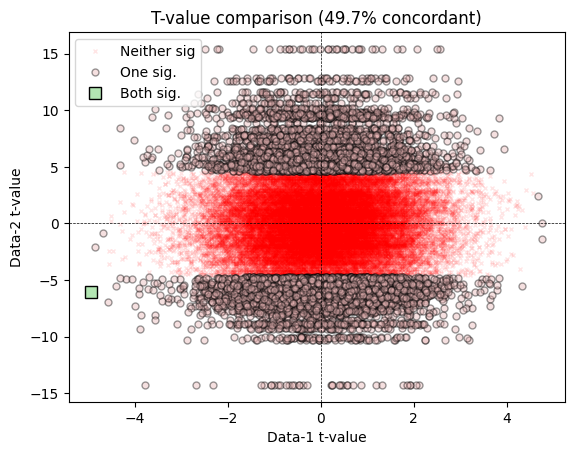

In [34]:
# vectorize for convenience
data1_t_vector = data1_t.flatten()
data1_p_vector = data1_p.flatten()
data2_t_vector = data2_t.flatten()
data2_p_vector = data2_p.flatten()

# find where one or both are significant
bothSig = (data1_p_vector<sigPthresh).astype(int) + (data2_p_vector<sigPthresh).astype(int)


# "concordancy" as same sign and at least one is significant
num = (np.sign(data1_t_vector)==np.sign(data2_t_vector)) & ((data1_p_vector<sigPthresh) | (data2_p_vector<sigPthresh))
den = (data1_p_vector<sigPthresh) | (data2_p_vector<sigPthresh)
concordance = 100 * num.sum() / den.sum()

# compare the two sets
plt.plot(data1_t_vector[bothSig==0],data2_t_vector[bothSig==0],'rx',markersize=3,alpha=.1,label='Neither sig')
plt.plot(data1_t_vector[bothSig==1],data2_t_vector[bothSig==1],'ko',markerfacecolor=[.9,.7,.7],markersize=5,alpha=.4,label='One sig.')
plt.plot(data1_t_vector[bothSig==2],data2_t_vector[bothSig==2],'ks',markerfacecolor=[.7,.9,.7],markersize=8,label='Both sig.')
plt.axhline(0,color='k',linestyle='--',linewidth=.5)
plt.axvline(0,color='k',linestyle='--',linewidth=.5)
plt.legend()

plt.gca().set(xlabel='Data-1 t-value',ylabel='Data-2 t-value',title=f'T-value comparison ({concordance:.1f}% concordant)')
plt.show()
# aka the pistachio canoli plot :P